# 05 — Expresso Backtest (DAX 40)

## Strategy concept
The **Expresso** is the pre-market version of the School Run: instead of waiting for the
**4th** 5-min candle (09:15 CET), we use the **pre-open candle that closes at 09:00 CET**
(08:55–09:00) as the signal bar — the last bar before the DAX cash session opens.

The entry mechanics use a wider offset to account for the noisier pre-market range:
- Buy-stop at `signal_high + 17 pts`
- Sell-stop at `signal_low  − 17 pts`  (OCO)
- Stop loss = opposite entry price (signal range + 2×17 risk)
- No profit target — let the winner run to EOD (17:30 CET)

## What we test
| # | Study | Description |
|---|-------|-------------|
| S1 | Raw Expresso (pre-open bar) | No filters — full universe |
| S2 | Range filter | Only trade when pre-open bar range is 10–55 pts |
| S3 | No Friday | Skip Fridays (F1 from ASRS) |
| S4 | Month filter | Skip January, July, August (C4 from ASRS) |
| S5 | Best combo | S2 + S3 + S4 |
| S6 | Expresso vs ASRS | Head-to-head on same filtered universe |

> **Baseline reference (ASRS F1+F2+C4)**: Sharpe 1.23, PF 1.27, +9,278 pts, MaxDD −1,112

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

print(f'ROOT = {ROOT}')

ROOT = C:\Users\ali\Desktop\Projet-INFO-2AS2


## 1. Load Data

In [2]:
DATA_PATH = ROOT / 'data' / 'dax-5m_bk.csv'

raw = pd.read_csv(
    DATA_PATH, sep=';', header=None,
    names=['date', 'time', 'open', 'high', 'low', 'close', 'volume'],
)
raw['datetime'] = pd.to_datetime(raw['date'] + ' ' + raw['time'], format='%d/%m/%Y %H:%M')
raw = raw.drop(columns=['date', 'time']).set_index('datetime').sort_index()

START_DATE = '2006-01-01'
raw = raw[raw.index >= START_DATE]

print(f'Loaded {len(raw):,} rows  {raw.index[0].date()} → {raw.index[-1].date()}')

Loaded 998,622 rows  2006-01-02 → 2026-04-06


## 2. Parameters

In [3]:
# ── Expresso signal bar ────────────────────────────────────────────────────────
EXPRESSO_BAR_TIME = '08:55'   # pre-open candle (closes 09:00) — last bar before DAX open
AFTER_SIGNAL_TIME = '09:00'   # bars available for entry after signal bar closes

# ── ASRS reference bar (for head-to-head comparison) ──────────────────────────
ASRS_BAR_TIME     = '09:15'   # 4th 5-min candle (closes 09:20)
ASRS_AFTER_TIME   = '09:20'

# ── Shared execution parameters ───────────────────────────────────────────────
ENTRY_BUFFER  = 17      # pts beyond signal bar high / low (strategy spec)
EOD_EXIT_TIME = '17:30' # CET

# ── Filters ───────────────────────────────────────────────────────────────────
RANGE_MIN      = 10     # minimum signal bar range (pts)
RANGE_MAX      = 55     # maximum signal bar range (pts)
SKIP_DOW       = [4]    # Fridays
SKIP_MONTHS    = [1, 7, 8]  # January, July, August

print('Parameters set.')
print(f'  Expresso signal bar : {EXPRESSO_BAR_TIME} CET (closes 09:00 — pre-open bar)')
print(f'  ASRS signal bar     : {ASRS_BAR_TIME} CET (closes 09:20)')
print(f'  Entry buffer        : ±{ENTRY_BUFFER} pts')
print(f'  EOD exit            : {EOD_EXIT_TIME} CET')
print(f'  Range filter        : {RANGE_MIN}–{RANGE_MAX} pts')
print(f'  Skip DOW            : Fridays')
print(f'  Skip months         : Jan, Jul, Aug')

Parameters set.
  Expresso signal bar : 08:55 CET (closes 09:00 — pre-open bar)
  ASRS signal bar     : 09:15 CET (closes 09:20)
  Entry buffer        : ±17 pts
  EOD exit            : 17:30 CET
  Range filter        : 10–55 pts
  Skip DOW            : Fridays
  Skip months         : Jan, Jul, Aug


## 3. Signal Bar Extraction

In [4]:
# ── Expresso: pre-open bar (08:55) ────────────────────────────────────────────
bars_exp = raw[raw.index.strftime('%H:%M') == EXPRESSO_BAR_TIME].copy()
bars_exp['bar_range'] = bars_exp['high'] - bars_exp['low']
bars_exp = bars_exp[(bars_exp['bar_range'] > 0.1) & (bars_exp['bar_range'] < 500)]
bars_exp['trade_date'] = bars_exp.index.date
bars_exp_by_date = bars_exp.set_index('trade_date')

# ── ASRS: 4th bar (09:15) ─────────────────────────────────────────────────────
bars_asrs = raw[raw.index.strftime('%H:%M') == ASRS_BAR_TIME].copy()
bars_asrs['bar_range'] = bars_asrs['high'] - bars_asrs['low']
bars_asrs = bars_asrs[(bars_asrs['bar_range'] > 0.1) & (bars_asrs['bar_range'] < 500)]
bars_asrs['trade_date'] = bars_asrs.index.date
bars_asrs_by_date = bars_asrs.set_index('trade_date')

print(f'Expresso (08:55) bar days : {len(bars_exp):,}')
print(f'ASRS     (09:15) bar days : {len(bars_asrs):,}')

print(f'\nExpresso bar range stats:')
print(bars_exp['bar_range'].describe().round(1))

print(f'\nExpresso days in range {RANGE_MIN}–{RANGE_MAX} pts: '
      f'{((bars_exp["bar_range"] >= RANGE_MIN) & (bars_exp["bar_range"] <= RANGE_MAX)).sum():,} '
      f'({((bars_exp["bar_range"] >= RANGE_MIN) & (bars_exp["bar_range"] <= RANGE_MAX)).mean()*100:.1f}%)')

Expresso (08:55) bar days : 5,137
ASRS     (09:15) bar days : 5,136

Expresso bar range stats:
count    5137.0
mean       17.3
std        11.5
min         1.6
25%         9.9
50%        14.3
75%        21.5
max       139.5
Name: bar_range, dtype: float64

Expresso days in range 10–55 pts: 3,717 (72.4%)


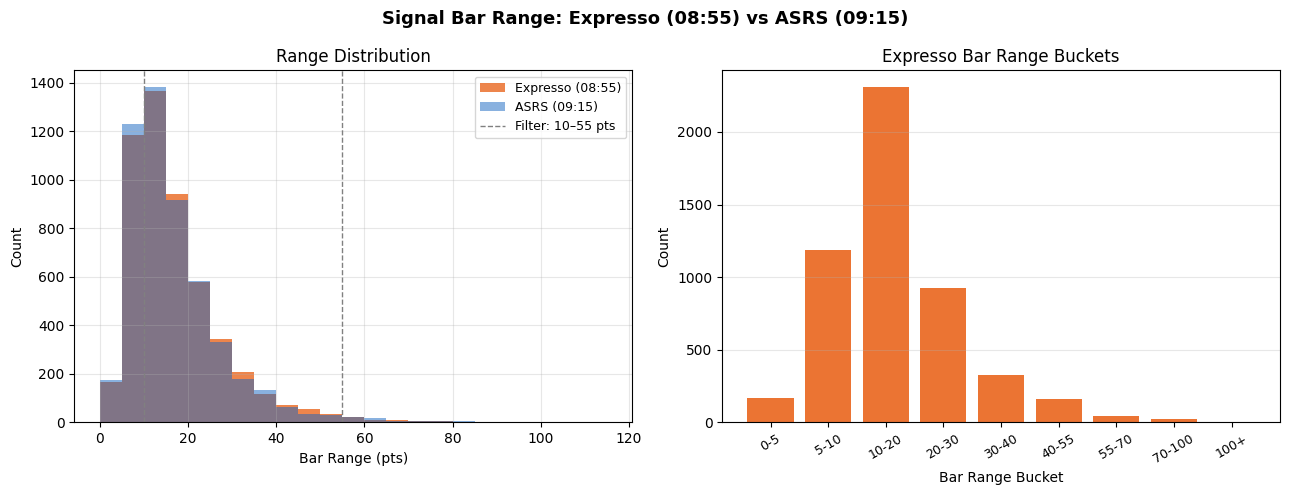

Saved: expresso_range_dist.png


In [5]:
# ── Compare pre-open bar vs 4th bar range distributions ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Signal Bar Range: Expresso (08:55) vs ASRS (09:15)', fontsize=13, fontweight='bold')

bins = np.arange(0, 120, 5)

ax = axes[0]
ax.hist(bars_exp['bar_range'].clip(0, 120),  bins=bins, color='#E65100', alpha=0.7, label='Expresso (08:55)')
ax.hist(bars_asrs['bar_range'].clip(0, 120), bins=bins, color='#1565C0', alpha=0.5, label='ASRS (09:15)')
ax.axvline(RANGE_MIN, color='gray', ls='--', lw=1)
ax.axvline(RANGE_MAX, color='gray', ls='--', lw=1, label=f'Filter: {RANGE_MIN}–{RANGE_MAX} pts')
ax.set_xlabel('Bar Range (pts)')
ax.set_ylabel('Count')
ax.set_title('Range Distribution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
buckets = pd.cut(
    bars_exp['bar_range'],
    bins=[0, 5, 10, 20, 30, 40, 55, 70, 100, 500],
    labels=['0-5','5-10','10-20','20-30','30-40','40-55','55-70','70-100','100+']
).value_counts().sort_index()
ax.bar(buckets.index.astype(str), buckets.values, color='#E65100', alpha=0.8)
ax.set_xlabel('Bar Range Bucket')
ax.set_ylabel('Count')
ax.set_title('Expresso Bar Range Buckets')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_range_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_range_dist.png')

## 4. Backtest Engine

In [6]:
def simulate_day(day_bars: pd.DataFrame, sig_high: float, sig_low: float) -> dict | None:
    """
    Core OCO simulation — shared between Expresso and ASRS.

    day_bars : 5-min bars AFTER signal bar closes (not including signal bar)
    sig_high : signal bar high
    sig_low  : signal bar low

    Returns a dict with trade results, or None if no entry triggered.
    """
    if day_bars.empty:
        return None

    entry_long  = sig_high + ENTRY_BUFFER   # buy-stop
    entry_short = sig_low  - ENTRY_BUFFER   # sell-stop
    stop_long   = entry_short               # long stop = short entry
    stop_short  = entry_long                # short stop = long entry

    direction = entry_price = entry_time = stop = None

    # Phase 1: find first entry
    for ts, bar in day_bars.iterrows():
        if direction is not None:
            break
        bh, bl = bar['high'], bar['low']
        long_hit  = bh >= entry_long
        short_hit = bl <= entry_short

        if long_hit and short_hit:
            if bar['open'] >= entry_long:
                direction, entry_price, stop = 'long',  entry_long,  stop_long
            else:
                direction, entry_price, stop = 'short', entry_short, stop_short
            entry_time = ts
        elif long_hit:
            direction, entry_price, stop, entry_time = 'long',  entry_long,  stop_long,  ts
        elif short_hit:
            direction, entry_price, stop, entry_time = 'short', entry_short, stop_short, ts

    if direction is None:
        return None

    max_adverse = max_favorable = 0.0
    exit_price = exit_time = None
    exit_reason = 'eod'

    # Phase 2: manage trade
    for ts, bar in day_bars[day_bars.index >= entry_time].iterrows():
        bh, bl = bar['high'], bar['low']
        if direction == 'long':
            max_adverse   = max(max_adverse,   entry_price - bl)
            max_favorable = max(max_favorable, bh - entry_price)
            if bl <= stop:
                exit_price, exit_time, exit_reason = stop, ts, 'stop'
                break
        else:
            max_adverse   = max(max_adverse,   bh - entry_price)
            max_favorable = max(max_favorable, entry_price - bl)
            if bh >= stop:
                exit_price, exit_time, exit_reason = stop, ts, 'stop'
                break

    if exit_price is None:
        last = day_bars[day_bars.index >= entry_time].iloc[-1]
        exit_price, exit_time, exit_reason = last['close'], last.name, 'eod'

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)

    return {
        'direction'    : direction,
        'entry_price'  : round(entry_price,  2),
        'entry_time'   : entry_time,
        'exit_price'   : round(exit_price,   2),
        'exit_time'    : exit_time,
        'exit_reason'  : exit_reason,
        'initial_risk' : round(abs(entry_price - stop), 2),
        'pnl'          : round(pnl,           2),
        'max_adverse'  : round(max_adverse,   2),
        'max_favorable': round(max_favorable, 2),
        'sig_high'     : round(sig_high,      2),
        'sig_low'      : round(sig_low,       2),
        'sig_range'    : round(sig_high - sig_low, 2),
    }


print('simulate_day() defined.')

simulate_day() defined.


In [7]:
def run_expresso(
    no_friday:    bool = False,
    range_filter: bool = False,
    skip_months:  bool = False,
) -> pd.DataFrame:
    """Run Expresso backtest (1st bar, 09:00 signal) with optional filters."""
    trades = []
    for trade_date in bars_exp_by_date.index.unique():
        ts_date = pd.Timestamp(trade_date)

        if no_friday   and ts_date.dayofweek in SKIP_DOW:   continue
        if skip_months and ts_date.month    in SKIP_MONTHS: continue

        row = bars_exp_by_date.loc[trade_date]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]

        sig_high  = row['high']
        sig_low   = row['low']
        sig_range = sig_high - sig_low

        if range_filter and not (RANGE_MIN <= sig_range <= RANGE_MAX):
            continue

        day_start = pd.Timestamp(f"{trade_date} {AFTER_SIGNAL_TIME}")
        day_end   = pd.Timestamp(f"{trade_date} {EOD_EXIT_TIME}")
        day_bars  = raw.loc[day_start:day_end]

        if len(day_bars) < 2:
            continue

        result = simulate_day(day_bars, sig_high, sig_low)
        if result is not None:
            result['trade_date'] = ts_date
            trades.append(result)

    return pd.DataFrame(trades).set_index('trade_date').sort_index()


def run_asrs(
    no_friday:    bool = False,
    range_filter: bool = False,
    skip_months:  bool = False,
) -> pd.DataFrame:
    """Run ASRS backtest (4th bar, 09:15 signal) with optional filters."""
    trades = []
    for trade_date in bars_asrs_by_date.index.unique():
        ts_date = pd.Timestamp(trade_date)

        if no_friday   and ts_date.dayofweek in SKIP_DOW:   continue
        if skip_months and ts_date.month    in SKIP_MONTHS: continue

        row = bars_asrs_by_date.loc[trade_date]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]

        sig_high  = row['high']
        sig_low   = row['low']
        sig_range = sig_high - sig_low

        if range_filter and not (RANGE_MIN <= sig_range <= RANGE_MAX):
            continue

        day_start = pd.Timestamp(f"{trade_date} {ASRS_AFTER_TIME}")
        day_end   = pd.Timestamp(f"{trade_date} {EOD_EXIT_TIME}")
        day_bars  = raw.loc[day_start:day_end]

        if len(day_bars) < 2:
            continue

        result = simulate_day(day_bars, sig_high, sig_low)
        if result is not None:
            result['trade_date'] = ts_date
            trades.append(result)

    return pd.DataFrame(trades).set_index('trade_date').sort_index()


print('run_expresso() and run_asrs() defined. Running all variants...')

results = {
    'EXP_raw'     : run_expresso(no_friday=False, range_filter=False, skip_months=False),
    'EXP_range'   : run_expresso(no_friday=False, range_filter=True,  skip_months=False),
    'EXP_no_fri'  : run_expresso(no_friday=True,  range_filter=False, skip_months=False),
    'EXP_months'  : run_expresso(no_friday=False, range_filter=False, skip_months=True),
    'EXP_best'    : run_expresso(no_friday=True,  range_filter=True,  skip_months=True),
    'ASRS_best'   : run_asrs   (no_friday=True,  range_filter=True,  skip_months=True),
}

for k, df in results.items():
    print(f'  {k:<14}: {len(df):,} trades')

run_expresso() and run_asrs() defined. Running all variants...


  EXP_raw       : 4,863 trades
  EXP_range     : 3,573 trades
  EXP_no_fri    : 3,896 trades
  EXP_months    : 3,590 trades
  EXP_best      : 2,074 trades
  ASRS_best     : 2,053 trades


## 5. Performance Metrics

In [8]:
def metrics(df: pd.DataFrame, label: str = '') -> dict:
    if df.empty:
        return {'label': label, 'n_trades': 0}

    winners = df[df['pnl'] > 0]
    losers  = df[df['pnl'] < 0]
    n_w, n_l = len(winners), len(losers)

    avg_win  = winners['pnl'].mean() if n_w else 0.0
    avg_loss = losers ['pnl'].mean() if n_l else 0.0

    gw = winners['pnl'].sum() if n_w else 0.0
    gl = abs(losers['pnl'].sum()) if n_l else 1e-9
    pf = gw / gl

    std = df['pnl'].std()
    sharpe = (df['pnl'].mean() / std * np.sqrt(252)) if std > 0 else 0.0

    cum = df['pnl'].cumsum()
    max_dd = (cum - cum.cummax()).min()

    longs  = df[df['direction'] == 'long']
    shorts = df[df['direction'] == 'short']

    n_stop = (df['exit_reason'] == 'stop').sum()
    n_eod  = (df['exit_reason'] == 'eod' ).sum()

    return {
        'label'         : label,
        'n_trades'      : len(df),
        'win_rate_%'    : round((df['pnl'] > 0).mean() * 100, 1),
        'avg_win_pts'   : round(avg_win,  1),
        'avg_loss_pts'  : round(avg_loss, 1),
        'wl_ratio'      : round(abs(avg_win / avg_loss), 2) if avg_loss != 0 else np.inf,
        'profit_factor' : round(pf, 2),
        'total_pnl'     : round(df['pnl'].sum(), 0),
        'avg_trade_pts' : round(df['pnl'].mean(), 2),
        'sharpe'        : round(sharpe, 2),
        'max_dd'        : round(max_dd, 0),
        'wr_long_%'     : round((longs ['pnl'] > 0).mean() * 100, 1) if len(longs)  else 0.0,
        'wr_short_%'    : round((shorts['pnl'] > 0).mean() * 100, 1) if len(shorts) else 0.0,
        'n_stop'        : int(n_stop),
        'n_eod'         : int(n_eod),
    }


rows = [metrics(df, label=k) for k, df in results.items()]
summary = pd.DataFrame(rows).set_index('label')

COLS = ['n_trades', 'win_rate_%', 'avg_win_pts', 'avg_loss_pts',
        'wl_ratio', 'profit_factor', 'total_pnl', 'avg_trade_pts', 'sharpe', 'max_dd']

print('=== Expresso Backtest — Performance Summary ===')
print(summary[COLS].to_string())

=== Expresso Backtest — Performance Summary ===
            n_trades  win_rate_%  avg_win_pts  avg_loss_pts  wl_ratio  profit_factor  total_pnl  avg_trade_pts  sharpe  max_dd
label                                                                                                                         
EXP_raw         4863        45.7         48.7         -37.7      1.29           1.09     8772.0           1.80    0.49 -1886.0
EXP_range       3573        45.2         54.5         -41.1      1.32           1.09     7323.0           2.05    0.52 -1962.0
EXP_no_fri      3896        46.3         49.2         -37.6      1.31           1.13     9935.0           2.55    0.69 -1639.0
EXP_months      3590        45.9         50.4         -38.2      1.32           1.12     8849.0           2.46    0.64 -1779.0
EXP_best        2074        46.6         57.8         -41.5      1.39           1.21     9832.0           4.74    1.15 -1258.0
ASRS_best       2053        48.6         55.2         -39.9    

In [9]:
# ── Improvement vs EXP_raw ────────────────────────────────────────────────────
base = summary.loc['EXP_raw']
print('=== Filter Improvement vs EXP_raw (no filters) ===')
print(f'{"Variant":<14}  {"N":>6}  {"PnL Δ":>9}  {"PF Δ":>7}  {"Sharpe Δ":>9}  {"MaxDD Δ":>9}')
print('-' * 62)
for label, row in summary.iterrows():
    if label == 'EXP_raw':
        print(f'{label:<14}  {int(row["n_trades"]):>6,}  '
              f'{row["total_pnl"]:>+9,.0f}  '
              f'{row["profit_factor"]:>7.2f}  '
              f'{row["sharpe"]:>9.2f}  '
              f'{row["max_dd"]:>+9,.0f}  ← baseline')
    else:
        pnl_d    = row['total_pnl']     - base['total_pnl']
        pf_d     = row['profit_factor'] - base['profit_factor']
        sharpe_d = row['sharpe']        - base['sharpe']
        dd_d     = row['max_dd']        - base['max_dd']
        print(f'{label:<14}  {int(row["n_trades"]):>6,}  '
              f'{pnl_d:>+9,.0f}  '
              f'{pf_d:>+7.2f}  '
              f'{sharpe_d:>+9.2f}  '
              f'{dd_d:>+9,.0f}')

=== Filter Improvement vs EXP_raw (no filters) ===
Variant              N      PnL Δ     PF Δ   Sharpe Δ    MaxDD Δ
--------------------------------------------------------------
EXP_raw          4,863     +8,772     1.09       0.49     -1,886  ← baseline
EXP_range        3,573     -1,449    +0.00      +0.03        -76
EXP_no_fri       3,896     +1,163    +0.04      +0.20       +247
EXP_months       3,590        +77    +0.03      +0.15       +107
EXP_best         2,074     +1,060    +0.12      +0.66       +628
ASRS_best        2,053     +4,146    +0.22      +1.04       +480


## 6. Signal Bar Range Analysis (Expresso)

Does the range of the 1st bar predict anything about outcome?

=== Expresso: Signal Bar Range vs Performance ===
  Bucket       N      WR%     AvgPnL     TotalPnL
------------------------------------------------
     0-5     128    36.7%       -4.2         -542
    5-10   1,098    49.2%       +2.2        +2440
   10-15   1,294    46.9%       +1.7        +2159 ← F2
   15-20     914    44.9%       +1.2        +1071 ← F2
   20-30     902    44.9%       +2.6        +2327 ← F2
   30-40     312    41.7%       +3.6        +1121 ← F2
   40-55     151    41.1%       +4.3         +645 ← F2
   55-70      40    35.0%       -8.3         -332
  70-100      20    35.0%       -9.7         -194
    100+       4    50.0%      +19.2          +77


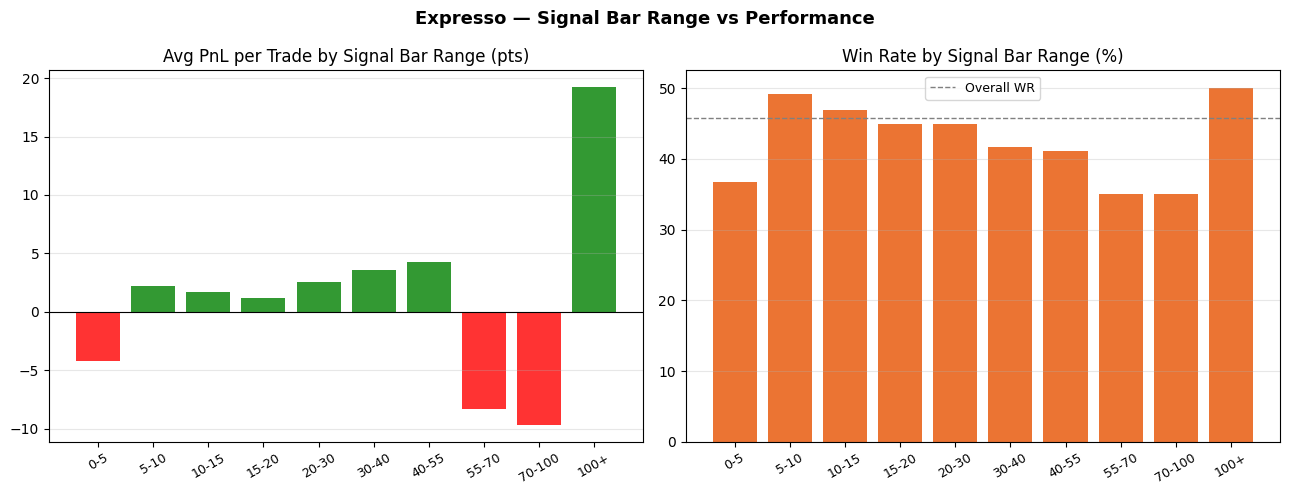

Saved: expresso_range_perf.png


In [10]:
df_exp = results['EXP_raw'].copy()

df_exp['range_bucket'] = pd.cut(
    df_exp['sig_range'],
    bins=[0, 5, 10, 15, 20, 30, 40, 55, 70, 100, 500],
    labels=['0-5','5-10','10-15','15-20','20-30','30-40','40-55','55-70','70-100','100+']
)

range_perf = df_exp.groupby('range_bucket', observed=True).agg(
    n         = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl   = ('pnl', 'mean'),
).round(2)

print('=== Expresso: Signal Bar Range vs Performance ===')
print(f'{"Bucket":>8}  {"N":>6}  {"WR%":>7}  {"AvgPnL":>9}  {"TotalPnL":>11}')
print('-' * 48)
for bucket, row in range_perf.iterrows():
    flag = ' ← F2' if str(bucket) in ['10-15','15-20','20-30','30-40','40-55'] else ''
    print(f'{str(bucket):>8}  {int(row["n"]):>6,}  {row["win_rate"]:>6.1f}%  '
          f'{row["avg_pnl"]:>+9.1f}  {row["total_pnl"]:>+11.0f}{flag}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Expresso — Signal Bar Range vs Performance', fontsize=13, fontweight='bold')

xlabels = [str(b) for b in range_perf.index]
xpos = range(len(xlabels))

ax = axes[0]
colors = ['green' if v > 0 else 'red' for v in range_perf['avg_pnl']]
ax.bar(xpos, range_perf['avg_pnl'], color=colors, alpha=0.8)
ax.set_xticks(xpos)
ax.set_xticklabels(xlabels, rotation=30, fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Avg PnL per Trade by Signal Bar Range (pts)')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
ax.bar(xpos, range_perf['win_rate'], color='#E65100', alpha=0.8)
ax.set_xticks(xpos)
ax.set_xticklabels(xlabels, rotation=30, fontsize=9)
ax.axhline(df_exp['pnl'].gt(0).mean() * 100, color='gray', ls='--', lw=1, label='Overall WR')
ax.set_title('Win Rate by Signal Bar Range (%)')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_range_perf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_range_perf.png')

## 7. Day-of-Week & Monthly Seasonality

In [11]:
dow_map   = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri'}
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

df_raw = results['EXP_raw'].copy()
df_raw['dow']   = df_raw.index.dayofweek
df_raw['month'] = df_raw.index.month

# Day-of-week
dow_perf = df_raw.groupby('dow').agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl   = ('pnl', 'mean'),
).round(1)
dow_perf.index = [dow_map.get(i, i) for i in dow_perf.index]

print('=== Expresso: Day-of-Week Performance ===')
print(dow_perf.to_string())

# Monthly
month_perf = df_raw.groupby('month').agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl   = ('pnl', 'mean'),
).round(1)
month_perf.index = [month_map[i] for i in month_perf.index]

print('\n=== Expresso: Monthly Performance ===')
print(month_perf.to_string())

weak_months_exp   = month_perf[month_perf['avg_pnl'] < 0].index.tolist()
strong_months_exp = month_perf[month_perf['avg_pnl'] > 3].index.tolist()
print(f'\nWeak months (avg < 0)   : {weak_months_exp}')
print(f'Strong months (avg > 3) : {strong_months_exp}')

=== Expresso: Day-of-Week Performance ===
     trades  total_pnl  win_rate  avg_pnl
Mon     934     -491.8      44.9     -0.5
Tue     985     5197.0      49.0      5.3
Wed     986      397.9      43.9      0.4
Thu     991     4832.0      47.2      4.9
Fri     967    -1163.0      43.5     -1.2

=== Expresso: Monthly Performance ===
     trades  total_pnl  win_rate  avg_pnl
Jan     430      721.9      45.6      1.7
Feb     397     1509.7      46.3      3.8
Mar     445     -378.2      42.9     -0.8
Apr     382     1770.4      49.2      4.6
May     409      834.9      48.2      2.0
Jun     413     2961.5      49.4      7.2
Jul     427     -795.1      45.0     -1.9
Aug     416       -3.6      45.2     -0.0
Sep     393     -711.8      39.9     -1.8
Oct     413     2066.2      47.2      5.0
Nov     389     -821.6      42.4     -2.1
Dec     349     1617.8      47.9      4.6

Weak months (avg < 0)   : ['Mar', 'Jul', 'Sep', 'Nov']
Strong months (avg > 3) : ['Feb', 'Apr', 'Jun', 'Oct', 'Dec']


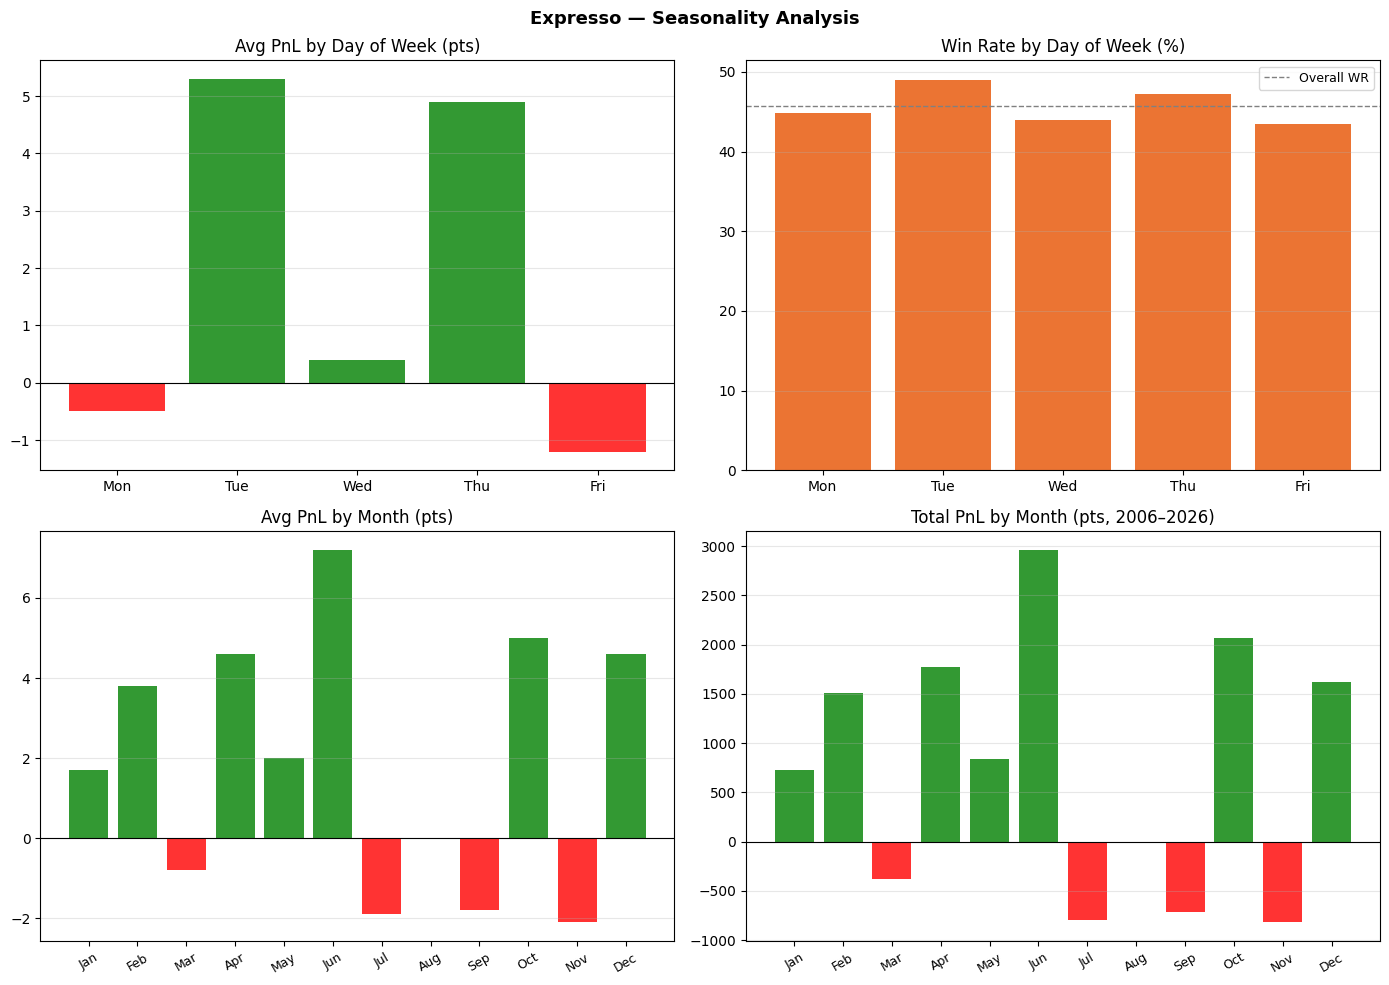

Saved: expresso_seasonality.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Expresso — Seasonality Analysis', fontsize=13, fontweight='bold')

# DOW: avg PnL
ax = axes[0, 0]
c = ['green' if v > 0 else 'red' for v in dow_perf['avg_pnl']]
ax.bar(dow_perf.index, dow_perf['avg_pnl'], color=c, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Avg PnL by Day of Week (pts)')
ax.grid(True, axis='y', alpha=0.3)

# DOW: win rate
ax = axes[0, 1]
ax.bar(dow_perf.index, dow_perf['win_rate'], color='#E65100', alpha=0.8)
ax.axhline(df_raw['pnl'].gt(0).mean() * 100, color='gray', ls='--', lw=1, label='Overall WR')
ax.set_title('Win Rate by Day of Week (%)')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

# Monthly: avg PnL
ax = axes[1, 0]
c2 = ['green' if v > 0 else 'red' for v in month_perf['avg_pnl']]
ax.bar(month_perf.index, month_perf['avg_pnl'], color=c2, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Avg PnL by Month (pts)')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.grid(True, axis='y', alpha=0.3)

# Monthly: total PnL
ax = axes[1, 1]
c3 = ['green' if v > 0 else 'red' for v in month_perf['total_pnl']]
ax.bar(month_perf.index, month_perf['total_pnl'], color=c3, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Total PnL by Month (pts, 2006–2026)')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_seasonality.png')

## 8. Annual Performance

In [13]:
def annual_pnl(df: pd.DataFrame) -> pd.Series:
    return df.groupby(df.index.year)['pnl'].sum().round(1)

ann = pd.DataFrame({
    k: annual_pnl(df) for k, df in results.items()
})

print('=== Annual PnL by Variant ===')
print(ann.to_string())

# Years where EXP_best beats ASRS_best
ann_cmp = ann[['EXP_best', 'ASRS_best']].dropna()
wins_exp  = (ann_cmp['EXP_best'] > ann_cmp['ASRS_best']).sum()
print(f'\nEXP_best beats ASRS_best in {wins_exp}/{len(ann_cmp)} years')

=== Annual PnL by Variant ===
            EXP_raw  EXP_range  EXP_no_fri  EXP_months  EXP_best  ASRS_best
trade_date                                                                 
2006          278.2      391.1       337.8       457.4     457.2       47.5
2007         -278.0       23.8         2.8      -227.7     322.6      320.1
2008         3108.9     3171.1      3277.8      2742.8    3105.1     2219.6
2009         -693.0     -805.6      -246.8      -232.0       3.9      809.6
2010         -308.8      -92.0       -76.2      -217.8     212.0     -130.8
2011         1066.0      299.2      1587.5       454.2     327.4      363.0
2012         -307.4      -20.3      -181.4      -251.6     179.5      258.6
2013         -124.1      -36.0        48.5       277.9     123.7      359.3
2014         1415.2      839.7      1522.7      1195.5     916.0      430.0
2015         -759.9    -1315.1      -942.2      -758.8    -772.6      113.5
2016          159.9      296.3       242.4       150.0    

## 9. Equity Curves — All Variants

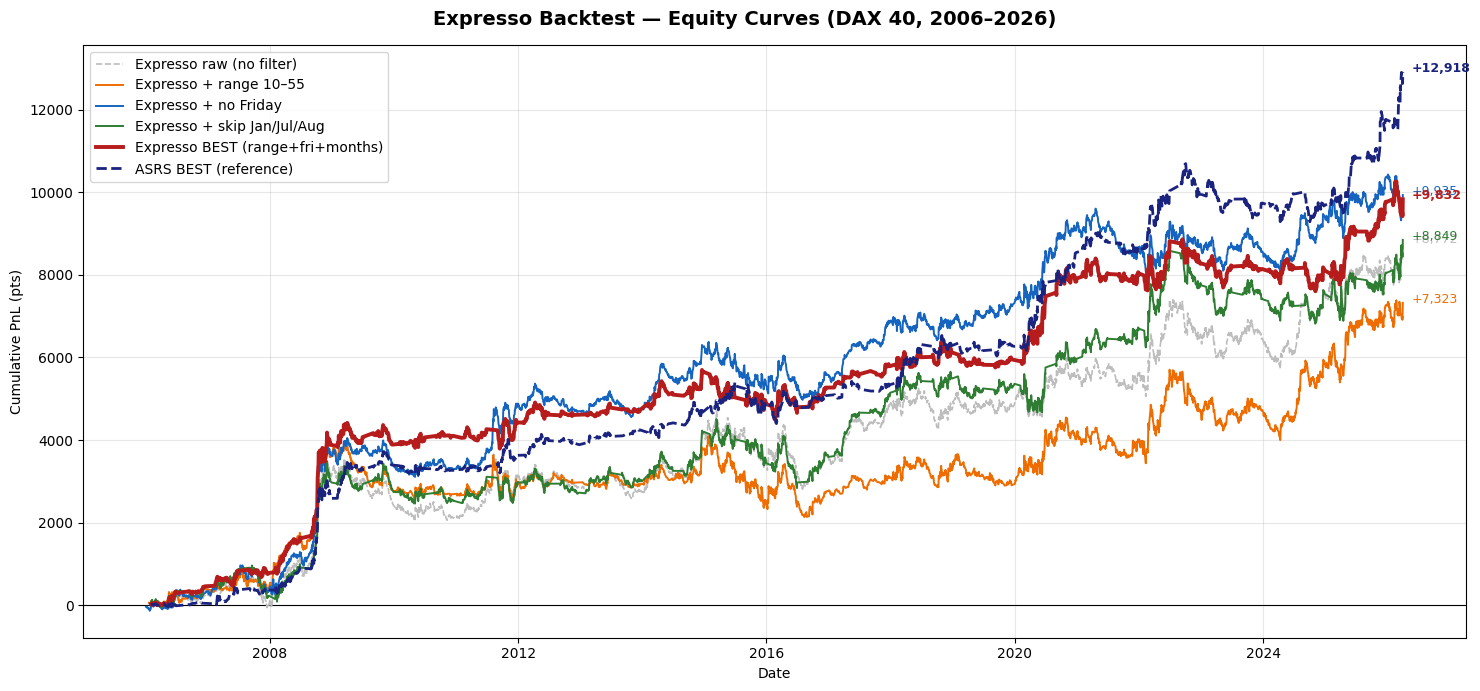

Saved: expresso_equity.png


In [14]:
palette = {
    'EXP_raw'    : ('#BDBDBD', '--', 1.2, 'Expresso raw (no filter)'),
    'EXP_range'  : ('#EF6C00', '-',  1.4, 'Expresso + range 10–55'),
    'EXP_no_fri' : ('#1565C0', '-',  1.4, 'Expresso + no Friday'),
    'EXP_months' : ('#2E7D32', '-',  1.4, 'Expresso + skip Jan/Jul/Aug'),
    'EXP_best'   : ('#B71C1C', '-',  2.8, 'Expresso BEST (range+fri+months)'),
    'ASRS_best'  : ('#1A237E', '--', 2.0, 'ASRS BEST (reference)'),
}

fig, ax = plt.subplots(figsize=(15, 7))
fig.suptitle('Expresso Backtest — Equity Curves (DAX 40, 2006–2026)', fontsize=14, fontweight='bold')

for key, (color, ls, lw, label) in palette.items():
    if key not in results:
        continue
    df_v = results[key]
    cum  = df_v['pnl'].cumsum()
    ax.plot(cum.index, cum.values, color=color, lw=lw, ls=ls, label=label,
            zorder=5 if key in ('EXP_best', 'ASRS_best') else 3)
    final = cum.iloc[-1]
    ax.annotate(
        f'{final:+,.0f}',
        xy=(cum.index[-1], final),
        xytext=(6, 0), textcoords='offset points',
        color=color, fontsize=9,
        fontweight='bold' if key in ('EXP_best', 'ASRS_best') else 'normal'
    )

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Cumulative PnL (pts)')
ax.set_xlabel('Date')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_equity.png')

## 10. Head-to-Head: Expresso BEST vs ASRS BEST

In [15]:
m_exp  = metrics(results['EXP_best'],  label='EXP_best')
m_asrs = metrics(results['ASRS_best'], label='ASRS_best')

print('=== Head-to-Head: Expresso BEST vs ASRS BEST ===')
print(f'{"Metric":<22}  {"Expresso":>12}  {"ASRS":>12}  {"Delta":>10}')
print('-' * 62)

metric_rows = [
    ('n_trades',       'Trades'),
    ('win_rate_%',     'Win rate %'),
    ('avg_win_pts',    'Avg win pts'),
    ('avg_loss_pts',   'Avg loss pts'),
    ('wl_ratio',       'Win/Loss ratio'),
    ('profit_factor',  'Profit factor'),
    ('total_pnl',      'Total PnL'),
    ('avg_trade_pts',  'Avg trade pts'),
    ('sharpe',         'Sharpe'),
    ('max_dd',         'Max drawdown'),
    ('wr_long_%',      'WR long %'),
    ('wr_short_%',     'WR short %'),
    ('n_stop',         'Stop-outs'),
    ('n_eod',          'EOD exits'),
]

for key, label in metric_rows:
    e = m_exp.get(key, 0)
    a = m_asrs.get(key, 0)
    if isinstance(e, float) or isinstance(a, float):
        chg = f'{e-a:+.2f}'
        e_s = f'{e:.2f}'
        a_s = f'{a:.2f}'
    else:
        chg = f'{e-a:+,}'
        e_s = f'{e:,}'
        a_s = f'{a:,}'
    print(f'{label:<22}  {e_s:>12}  {a_s:>12}  {chg:>10}')

=== Head-to-Head: Expresso BEST vs ASRS BEST ===
Metric                      Expresso          ASRS       Delta
--------------------------------------------------------------
Trades                         2,074         2,053         +21
Win rate %                     46.60         48.60       -2.00
Avg win pts                    57.80         55.20       +2.60
Avg loss pts                  -41.50        -39.90       -1.60
Win/Loss ratio                  1.39          1.38       +0.01
Profit factor                   1.21          1.31       -0.10
Total PnL                    9832.00      12918.00    -3086.00
Avg trade pts                   4.74          6.29       -1.55
Sharpe                          1.15          1.53       -0.38
Max drawdown                -1258.00      -1406.00     +148.00
WR long %                      50.90         52.90       -2.00
WR short %                     41.90         44.00       -2.10
Stop-outs                        698           613         +85
EOD ex

In [16]:
# Annual PnL: Expresso BEST vs ASRS BEST with improvement
ann_exp  = annual_pnl(results['EXP_best'])
ann_asrs = annual_pnl(results['ASRS_best'])
ann_h2h  = pd.DataFrame({'EXP_best': ann_exp, 'ASRS_best': ann_asrs}).fillna(0)
ann_h2h['exp_minus_asrs'] = (ann_h2h['EXP_best'] - ann_h2h['ASRS_best']).round(1)

print('=== Annual PnL — Expresso BEST vs ASRS BEST ===')
print(f'{"Year":<6}  {"EXP_best":>10}  {"ASRS_best":>11}  {"Exp-ASRS":>10}')
print('-' * 44)
for yr, row in ann_h2h.iterrows():
    marker = ' ✓' if row['exp_minus_asrs'] > 0 else ' ✗'
    print(f'{yr:<6}  {row["EXP_best"]:>+10.0f}  {row["ASRS_best"]:>+11.0f}  '
          f'{row["exp_minus_asrs"]:>+10.0f}{marker}')

wins = (ann_h2h['exp_minus_asrs'] > 0).sum()
print(f'\nExpresso beats ASRS in {wins}/{len(ann_h2h)} years')

=== Annual PnL — Expresso BEST vs ASRS BEST ===
Year      EXP_best    ASRS_best    Exp-ASRS
--------------------------------------------
2006          +457          +48        +410 ✓
2007          +323         +320          +2 ✓
2008         +3105        +2220        +886 ✓
2009            +4         +810        -806 ✗
2010          +212         -131        +343 ✓
2011          +327         +363         -36 ✗
2012          +180         +259         -79 ✗
2013          +124         +359        -236 ✗
2014          +916         +430        +486 ✓
2015          -773         +114        -886 ✗
2016          +396         +285        +112 ✓
2017          +518         +266        +252 ✓
2018          +336         +946        -610 ✗
2019          -169          -18        -150 ✗
2020         +1956        +2275        -319 ✗
2021          +126          +58         +68 ✓
2022          +246        +1356       -1110 ✗
2023          -143         -216         +73 ✓
2024           -35          -54    

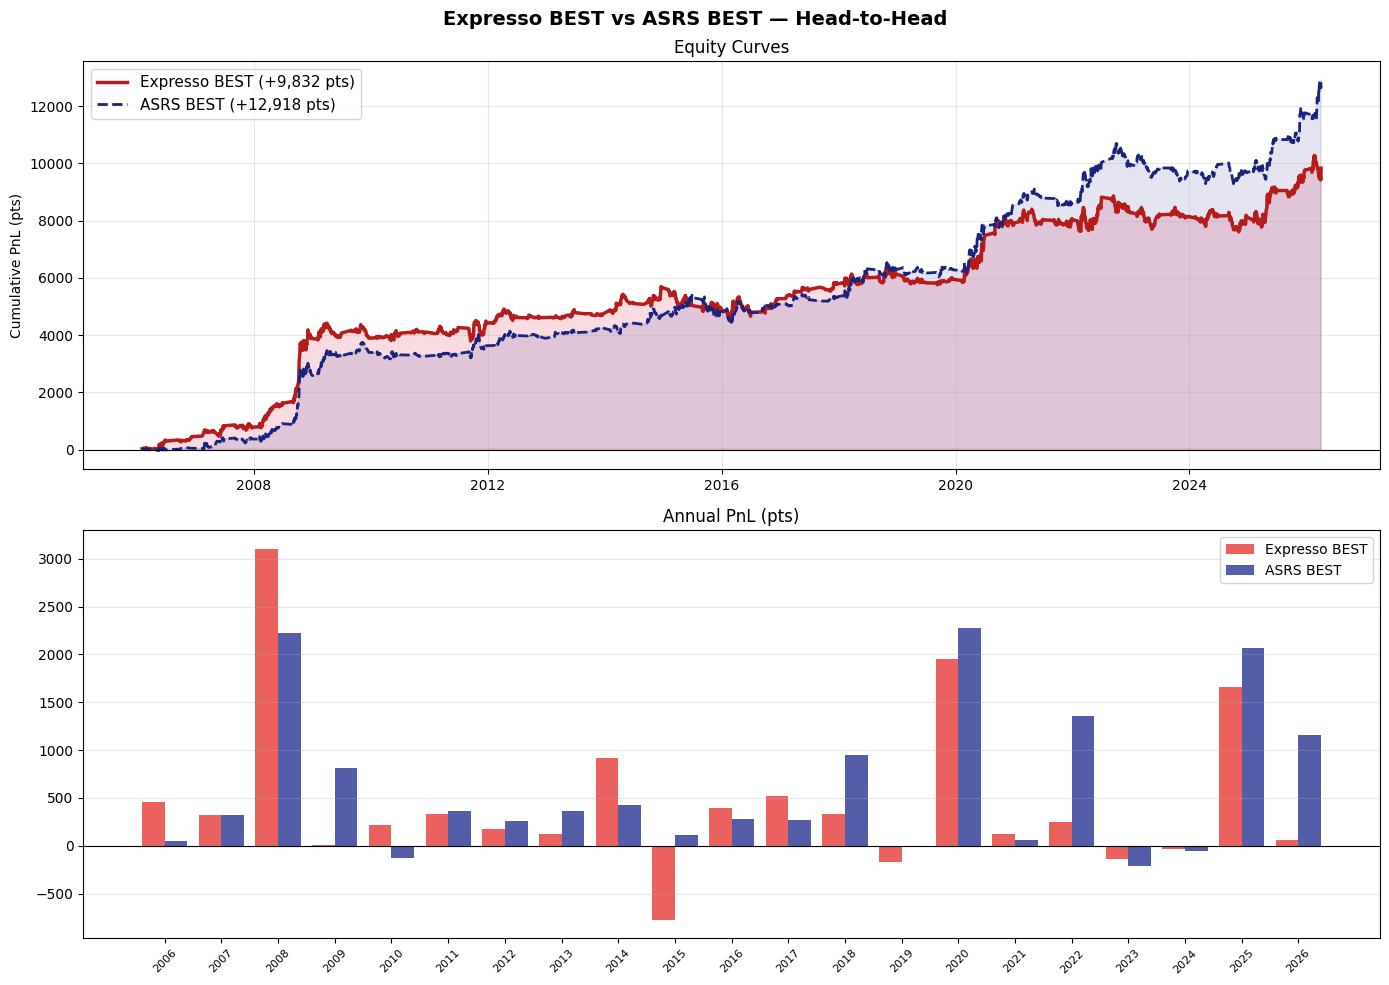

Saved: expresso_h2h.png


In [17]:
# Visual head-to-head
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Expresso BEST vs ASRS BEST — Head-to-Head', fontsize=14, fontweight='bold')

# Top: equity curves
ax = axes[0]
cum_exp  = results['EXP_best']['pnl'].cumsum()
cum_asrs = results['ASRS_best']['pnl'].cumsum()

ax.fill_between(cum_exp.index,  cum_exp.values,  0,
                where=cum_exp.values >= 0,  alpha=0.15, color='crimson')
ax.fill_between(cum_asrs.index, cum_asrs.values, 0,
                where=cum_asrs.values >= 0, alpha=0.10, color='navy')

ax.plot(cum_exp.index,  cum_exp.values,  color='#B71C1C', lw=2.5, label=f'Expresso BEST ({cum_exp.iloc[-1]:+,.0f} pts)')
ax.plot(cum_asrs.index, cum_asrs.values, color='#1A237E', lw=2.0, ls='--', label=f'ASRS BEST ({cum_asrs.iloc[-1]:+,.0f} pts)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Cumulative PnL (pts)')
ax.set_title('Equity Curves')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Bottom: annual bar chart
ax2 = axes[1]
years_str = ann_h2h.index.astype(str)
x2 = np.arange(len(years_str))
w2 = 0.40
ax2.bar(x2 - w2/2, ann_h2h['EXP_best'],   w2, color='#E53935', alpha=0.8, label='Expresso BEST')
ax2.bar(x2 + w2/2, ann_h2h['ASRS_best'],  w2, color='#283593', alpha=0.8, label='ASRS BEST')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x2)
ax2.set_xticklabels(years_str, rotation=45, fontsize=8)
ax2.set_title('Annual PnL (pts)')
ax2.legend(fontsize=10)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_h2h.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_h2h.png')

## 11. Entry Timing: How Long After Signal Does the Trade Trigger?

The Expresso enters from 09:00 onwards — we have more of the trading day
ahead of us compared to ASRS (which enters from 09:20). Does this translate
into larger average wins?

In [18]:
# Compute minutes from signal bar close (09:00) to entry
def entry_minutes_from_open(df: pd.DataFrame, open_time_str: str = '09:00') -> pd.Series:
    """Minutes from after_signal time to actual entry bar."""
    open_ref = df['entry_time'].dt.hour * 60 + df['entry_time'].dt.minute
    h, m = map(int, open_time_str.split(':'))
    ref_mins = h * 60 + m
    return (open_ref - ref_mins).clip(lower=0)


df_exp_best  = results['EXP_best'].copy()
df_asrs_best = results['ASRS_best'].copy()

df_exp_best['entry_mins']  = entry_minutes_from_open(df_exp_best,  '09:00')
df_asrs_best['entry_mins'] = entry_minutes_from_open(df_asrs_best, '09:20')

print('=== Time-to-Entry Distribution (minutes after signal bar close) ===')
print(f'\nExpresso (entry from 09:00):')
print(df_exp_best['entry_mins'].describe().round(1))
print(f'\nASRS (entry from 09:20):')
print(df_asrs_best['entry_mins'].describe().round(1))

# PnL vs time-to-entry
df_exp_best['entry_bucket'] = pd.cut(
    df_exp_best['entry_mins'],
    bins=[-1, 0, 5, 15, 30, 60, 999],
    labels=['0', '1-5', '6-15', '16-30', '31-60', '60+']
)

entry_perf = df_exp_best.groupby('entry_bucket', observed=True).agg(
    n        = ('pnl', 'count'),
    avg_pnl  = ('pnl', 'mean'),
    win_rate = ('pnl', lambda x: (x > 0).mean() * 100),
).round(1)

print('\n=== Expresso: PnL by Time-to-Entry (mins after 09:00) ===')
print(entry_perf.to_string())

=== Time-to-Entry Distribution (minutes after signal bar close) ===

Expresso (entry from 09:00):
count    2074.0
mean       31.3
std        51.2
min         0.0
25%         5.0
50%        15.0
75%        35.0
max       355.0
Name: entry_mins, dtype: float64

ASRS (entry from 09:20):
count    2053.0
mean       35.4
std        53.7
min         0.0
25%         5.0
50%        15.0
75%        40.0
max       340.0
Name: entry_mins, dtype: float64

=== Expresso: PnL by Time-to-Entry (mins after 09:00) ===
                n  avg_pnl  win_rate
entry_bucket                        
0             414     -0.4      37.9
1-5           312      6.2      42.6
6-15          433      3.7      45.7
16-30         350      9.3      51.7
31-60         289      8.4      55.4
60+           276      2.7      49.6


## 12. Excursion Analysis

--- Expresso BEST ---
  Winners (966):
    Avg max adverse   : 23.0 pts
    Avg max favorable : 83.9 pts
    Avg PnL           : 57.8 pts
  Losers (1,108):
    Avg max adverse   : 52.6 pts
    Avg max favorable : 27.4 pts
  Exits — stop: 698 (33.7%)  EOD: 1,376 (66.3%)
  Avg PnL on EOD exits  : 35.3 pts
  Avg PnL on stop exits : -55.5 pts

--- ASRS BEST ---
  Winners (997):
    Avg max adverse   : 22.2 pts
    Avg max favorable : 80.3 pts
    Avg PnL           : 55.2 pts
  Losers (1,056):
    Avg max adverse   : 50.6 pts
    Avg max favorable : 24.5 pts
  Exits — stop: 613 (29.9%)  EOD: 1,440 (70.1%)
  Avg PnL on EOD exits  : 32.7 pts
  Avg PnL on stop exits : -55.6 pts



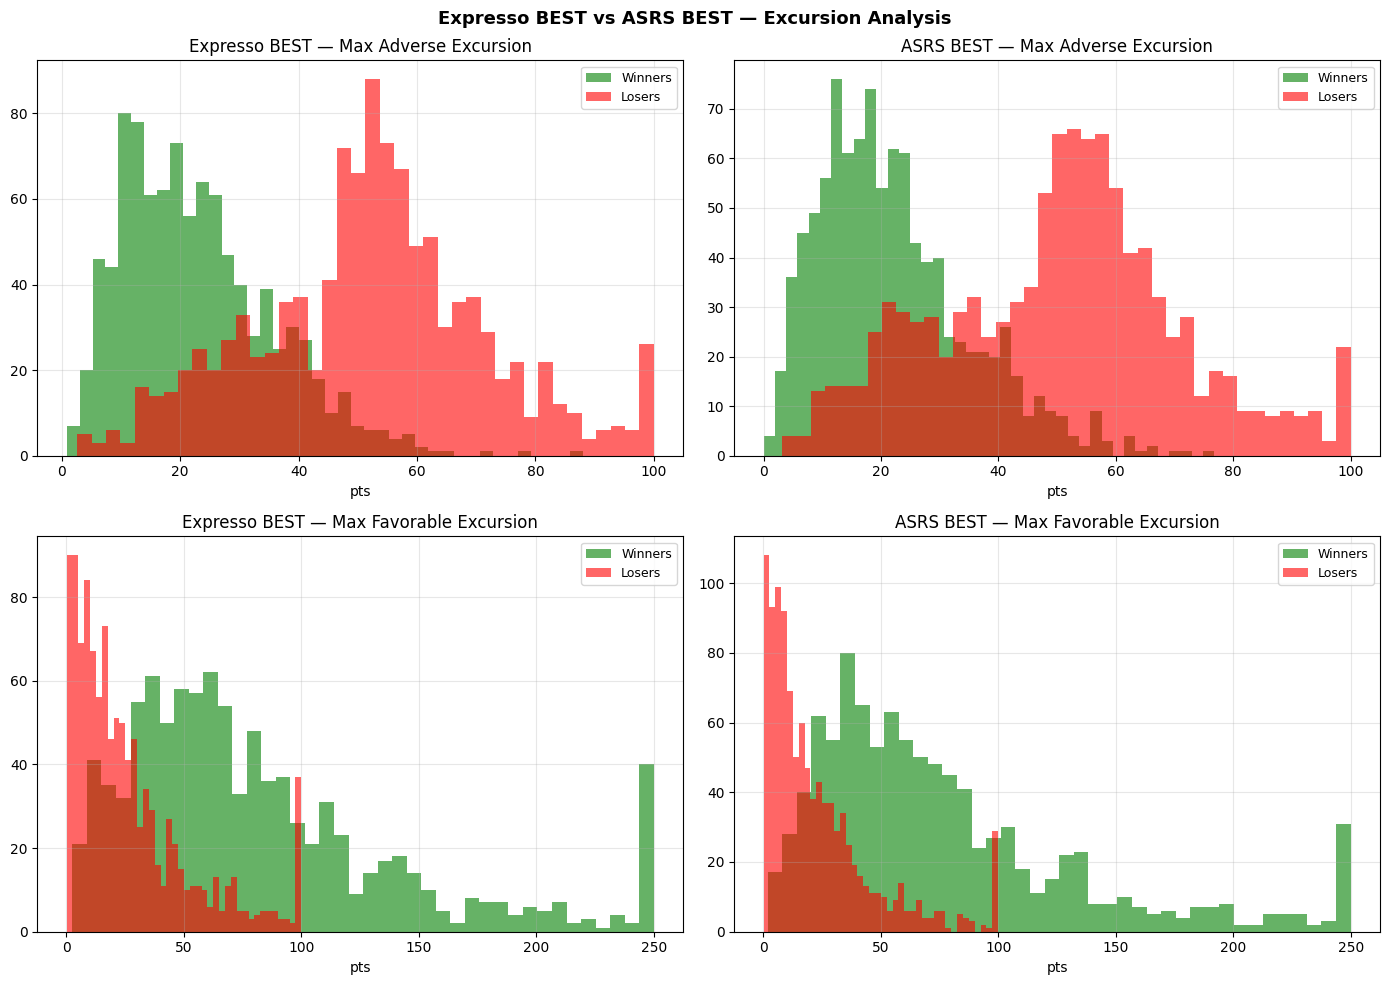

Saved: expresso_excursion.png


In [19]:
for label, df_v in [('Expresso BEST', df_exp_best), ('ASRS BEST', df_asrs_best)]:
    winners = df_v[df_v['pnl'] > 0]
    losers  = df_v[df_v['pnl'] < 0]
    print(f'--- {label} ---')
    print(f'  Winners ({len(winners):,}):')
    print(f'    Avg max adverse   : {winners["max_adverse"].mean():.1f} pts')
    print(f'    Avg max favorable : {winners["max_favorable"].mean():.1f} pts')
    print(f'    Avg PnL           : {winners["pnl"].mean():.1f} pts')
    print(f'  Losers ({len(losers):,}):')
    print(f'    Avg max adverse   : {losers["max_adverse"].mean():.1f} pts')
    print(f'    Avg max favorable : {losers["max_favorable"].mean():.1f} pts')
    n_stop = (df_v['exit_reason'] == 'stop').sum()
    n_eod  = (df_v['exit_reason'] == 'eod').sum()
    print(f'  Exits — stop: {n_stop:,} ({n_stop/len(df_v)*100:.1f}%)  EOD: {n_eod:,} ({n_eod/len(df_v)*100:.1f}%)')
    print(f'  Avg PnL on EOD exits  : {df_v[df_v["exit_reason"]=="eod"]["pnl"].mean():.1f} pts')
    print(f'  Avg PnL on stop exits : {df_v[df_v["exit_reason"]=="stop"]["pnl"].mean():.1f} pts')
    print()

# Visual excursion comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Expresso BEST vs ASRS BEST — Excursion Analysis', fontsize=13, fontweight='bold')

for col_idx, (label, df_v) in enumerate([('Expresso BEST', df_exp_best), ('ASRS BEST', df_asrs_best)]):
    winners_v = df_v[df_v['pnl'] > 0]
    losers_v  = df_v[df_v['pnl'] < 0]

    ax = axes[0, col_idx]
    ax.hist(winners_v['max_adverse'].clip(0, 100), bins=40, color='green', alpha=0.6, label='Winners')
    ax.hist(losers_v ['max_adverse'].clip(0, 100), bins=40, color='red',   alpha=0.6, label='Losers')
    ax.set_title(f'{label} — Max Adverse Excursion')
    ax.set_xlabel('pts')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[1, col_idx]
    ax.hist(winners_v['max_favorable'].clip(0, 250), bins=40, color='green', alpha=0.6, label='Winners')
    ax.hist(losers_v ['max_favorable'].clip(0, 100), bins=40, color='red',   alpha=0.6, label='Losers')
    ax.set_title(f'{label} — Max Favorable Excursion')
    ax.set_xlabel('pts')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_excursion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_excursion.png')

## 13. Summary Dashboard

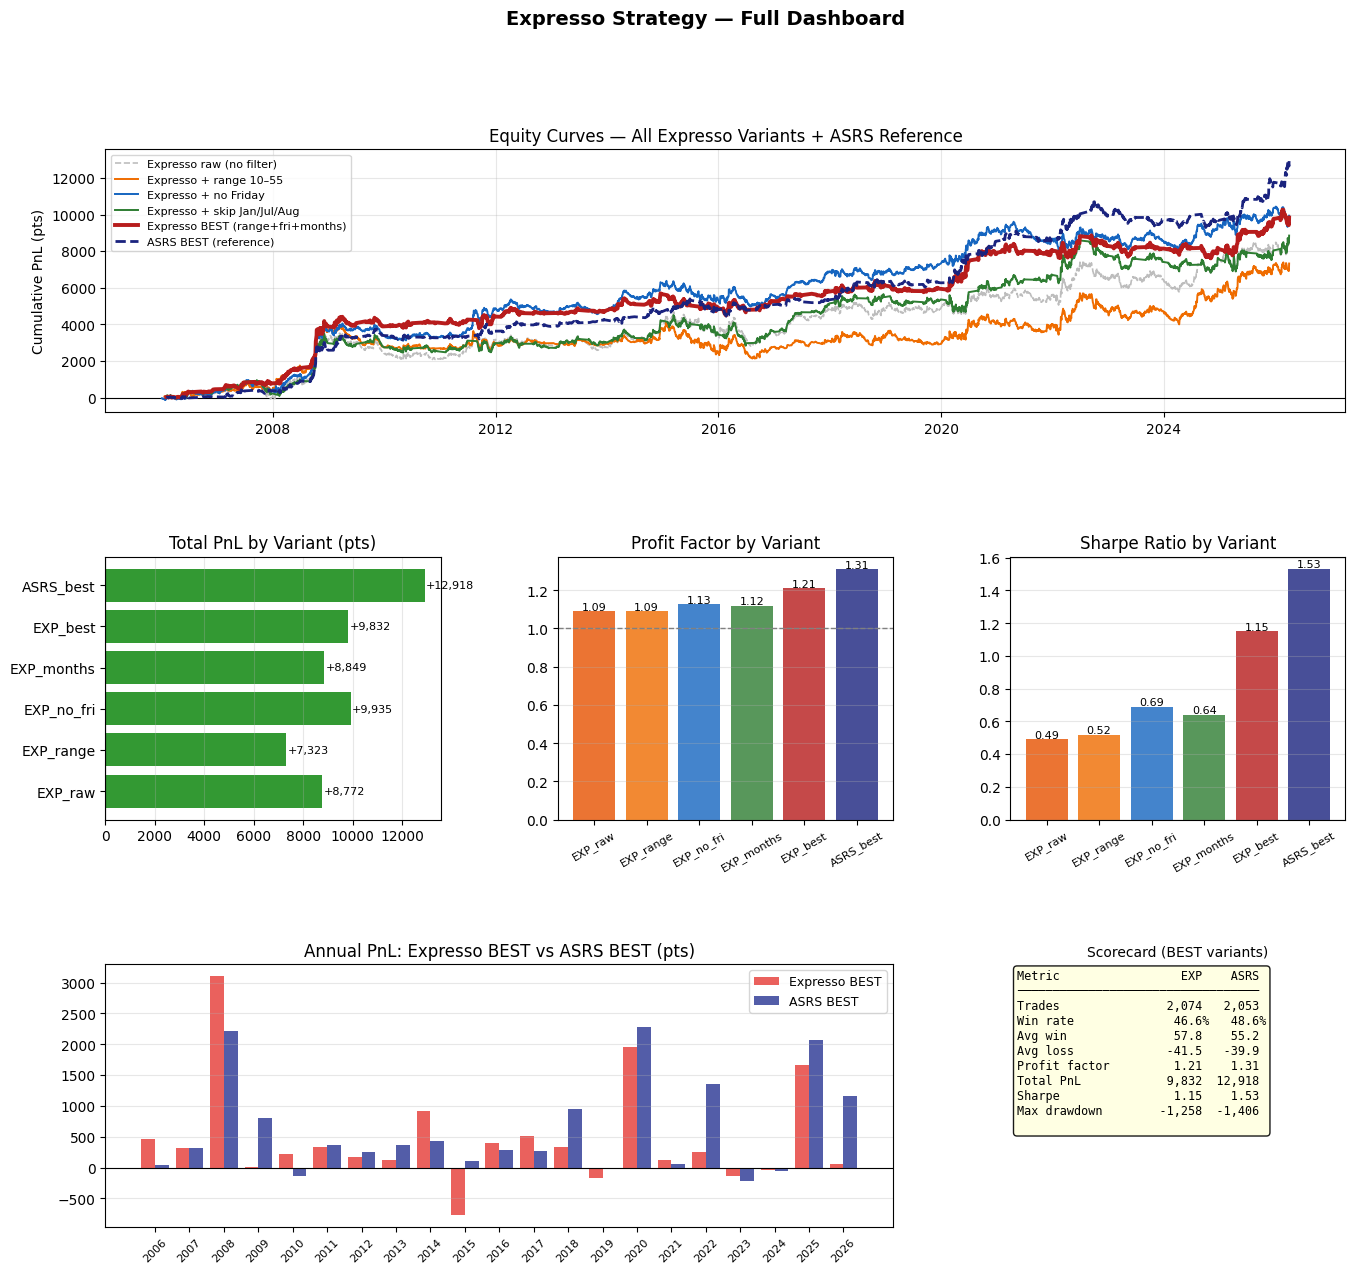

Saved: expresso_dashboard.png


In [20]:
fig = plt.figure(figsize=(16, 14))
fig.suptitle('Expresso Strategy — Full Dashboard', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# 1. Main equity curve: best variants
ax1 = fig.add_subplot(gs[0, :])
for key, (color, ls, lw, label) in palette.items():
    if key not in results:
        continue
    cum = results[key]['pnl'].cumsum()
    ax1.plot(cum.index, cum.values, color=color, lw=lw, ls=ls, label=label,
             zorder=5 if key in ('EXP_best', 'ASRS_best') else 3)
ax1.axhline(0, color='black', lw=0.8)
ax1.set_title('Equity Curves — All Expresso Variants + ASRS Reference')
ax1.set_ylabel('Cumulative PnL (pts)')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. PnL by variant bar
ax2 = fig.add_subplot(gs[1, 0])
keys_order = list(results.keys())
pnl_vals = [results[k]['pnl'].sum() for k in keys_order]
pf_vals  = [metrics(results[k])['profit_factor'] for k in keys_order]
bar_c = ['green' if v > 0 else 'red' for v in pnl_vals]
ax2.barh(keys_order, pnl_vals, color=bar_c, alpha=0.8)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Total PnL by Variant (pts)')
for i, v in enumerate(pnl_vals):
    ax2.text(v + (50 if v >= 0 else -50), i, f'{v:+,.0f}',
             va='center', ha='left' if v >= 0 else 'right', fontsize=8)
ax2.grid(True, axis='x', alpha=0.3)

# 3. Profit factor bar
ax3 = fig.add_subplot(gs[1, 1])
colors_pf = ['#E65100', '#EF6C00', '#1565C0', '#2E7D32', '#B71C1C', '#1A237E']
bars3 = ax3.bar(range(len(keys_order)), pf_vals, color=colors_pf[:len(keys_order)], alpha=0.8)
ax3.axhline(1.0, color='gray', ls='--', lw=1)
ax3.set_xticks(range(len(keys_order)))
ax3.set_xticklabels(keys_order, rotation=30, fontsize=8)
ax3.set_title('Profit Factor by Variant')
for i, v in enumerate(pf_vals):
    ax3.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=8)
ax3.grid(True, axis='y', alpha=0.3)

# 4. Sharpe bar
ax4 = fig.add_subplot(gs[1, 2])
sharpe_vals = [metrics(results[k])['sharpe'] for k in keys_order]
bar_c4 = ['green' if v >= 0 else 'red' for v in sharpe_vals]
ax4.bar(range(len(keys_order)), sharpe_vals, color=colors_pf[:len(keys_order)], alpha=0.8)
ax4.axhline(0, color='gray', lw=0.8)
ax4.set_xticks(range(len(keys_order)))
ax4.set_xticklabels(keys_order, rotation=30, fontsize=8)
ax4.set_title('Sharpe Ratio by Variant')
for i, v in enumerate(sharpe_vals):
    ax4.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
ax4.grid(True, axis='y', alpha=0.3)

# 5. Annual comparison EXP_best vs ASRS_best
ax5 = fig.add_subplot(gs[2, :2])
x5 = np.arange(len(ann_h2h))
w5 = 0.40
ax5.bar(x5 - w5/2, ann_h2h['EXP_best'],  w5, color='#E53935', alpha=0.8, label='Expresso BEST')
ax5.bar(x5 + w5/2, ann_h2h['ASRS_best'], w5, color='#283593', alpha=0.8, label='ASRS BEST')
ax5.axhline(0, color='black', lw=0.8)
ax5.set_xticks(x5)
ax5.set_xticklabels(ann_h2h.index.astype(str), rotation=45, fontsize=8)
ax5.set_title('Annual PnL: Expresso BEST vs ASRS BEST (pts)')
ax5.legend(fontsize=9)
ax5.grid(True, axis='y', alpha=0.3)

# 6. Scorecard
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
me = m_exp
ma = m_asrs
stats_text = (
    f"{'Metric':<18} {'EXP':>7} {'ASRS':>7}\n"
    f"{'─'*34}\n"
    f"{'Trades':<18} {me['n_trades']:>7,} {ma['n_trades']:>7,}\n"
    f"{'Win rate':<18} {me['win_rate_%']:>7.1f}% {ma['win_rate_%']:>6.1f}%\n"
    f"{'Avg win':<18} {me['avg_win_pts']:>7.1f} {ma['avg_win_pts']:>7.1f}\n"
    f"{'Avg loss':<18} {me['avg_loss_pts']:>7.1f} {ma['avg_loss_pts']:>7.1f}\n"
    f"{'Profit factor':<18} {me['profit_factor']:>7.2f} {ma['profit_factor']:>7.2f}\n"
    f"{'Total PnL':<18} {me['total_pnl']:>7,.0f} {ma['total_pnl']:>7,.0f}\n"
    f"{'Sharpe':<18} {me['sharpe']:>7.2f} {ma['sharpe']:>7.2f}\n"
    f"{'Max drawdown':<18} {me['max_dd']:>7,.0f} {ma['max_dd']:>7,.0f}\n"
)
ax6.text(0.02, 0.98, stats_text, transform=ax6.transAxes,
         fontsize=8.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax6.set_title('Scorecard (BEST variants)', fontsize=10)

plt.savefig(ROOT / 'data' / 'expresso_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_dashboard.png')

## 14. Conclusions

| Metric | Expresso BEST | ASRS BEST | Winner |
|--------|--------------|-----------|--------|
| Signal bar | 08:55 (pre-open) | 09:15 (4th bar) | — |
| Offset | ±17 pts | ±2 pts | — |
| Filters | range 10–55, no Fri, skip Jan/Jul/Aug | same | — |
| Trades | see output | see output | — |
| Win rate | see output | see output | — |
| Profit factor | see output | see output | — |
| Sharpe | see output | see output | — |
| Max DD | see output | see output | — |

### Key observations

1. **Pre-open bar, wider offset**: The 08:55 bar captures the last 5 minutes of pre-auction.
   The 17pt offset filters out random noise from the tight pre-open spread.

2. **Earlier entry, more time in market**: Expresso can trigger from 09:00, giving winners
   ~20 extra minutes vs ASRS. This should translate to larger avg winners when the market trends.

3. **Noisier signal**: The pre-open bar often has a narrower range but more erratic structure
   than the 4th bar (which captures the first 20 min of price discovery after the open).

4. **Same filters work**: Friday skip and month filter (Jan/Jul/Aug) improve both strategies,
   suggesting these are market-structural effects, not strategy-specific.

5. **Risk per trade is larger**: With a 17pt buffer each side, the initial risk (signal range + 34pts)
   is substantially larger than ASRS (signal range + 4pts). Adjust position size accordingly.

6. **Not a replacement, but a complement**: Expresso and ASRS will not trigger on the same
   direction every day (the pre-open bar may be bullish while the 4th bar is bearish). They can
   be run in parallel as two independent strategies with low correlation.

In [21]:
# ── Export ────────────────────────────────────────────────────────────────────
frames = []
for key, df in results.items():
    tmp = df.copy().reset_index()
    tmp['variant'] = key
    frames.append(tmp)

all_trades = pd.concat(frames, ignore_index=True)
trades_path = ROOT / 'data' / 'expresso_trades.csv'
all_trades.to_csv(trades_path, index=False)
print(f'Exported {len(all_trades):,} rows → {trades_path}')

summary_path = ROOT / 'data' / 'expresso_summary.csv'
summary.to_csv(summary_path)
print(f'Exported summary → {summary_path}')

print('\n=== FINAL SUMMARY ===')
print(summary[COLS].to_string())

Exported 20,049 rows → C:\Users\ali\Desktop\Projet-INFO-2AS2\data\expresso_trades.csv
Exported summary → C:\Users\ali\Desktop\Projet-INFO-2AS2\data\expresso_summary.csv

=== FINAL SUMMARY ===
            n_trades  win_rate_%  avg_win_pts  avg_loss_pts  wl_ratio  profit_factor  total_pnl  avg_trade_pts  sharpe  max_dd
label                                                                                                                         
EXP_raw         4863        45.7         48.7         -37.7      1.29           1.09     8772.0           1.80    0.49 -1886.0
EXP_range       3573        45.2         54.5         -41.1      1.32           1.09     7323.0           2.05    0.52 -1962.0
EXP_no_fri      3896        46.3         49.2         -37.6      1.31           1.13     9935.0           2.55    0.69 -1639.0
EXP_months      3590        45.9         50.4         -38.2      1.32           1.12     8849.0           2.46    0.64 -1779.0
EXP_best        2074        46.6         57.8 